### Student Performance & Study Habits Dataset
i've picked a dataset at random(mostly) to illustrate a potential data science workflow. this dataset has features that make it great for one of the two main tasks of supervised machine learning; classification; assigning a label. the other one is regression; predicting a continuos value.

if you look back at the previously shared notes there was mention of **features** and **targets**. in super simple "classification/labelling terms"; you've got a picture paired with its name. the appropriate algortithm is fed this (input-output) pair from which it builds 'statistical intuition' on the relationship between a picture and a name. with enough **input-output pairs** the trained algorithm/model has a more robust intuition and can identify new pictures (new input) and give the correct label/name (new output).

with the Student Performance & Study Habits dataset every column is a feature that helps us predict our target in the `final_grade` column. though we have A through F as possible labels we'll make some choices on 'thresholds'(look up **decision boundaries**) for passing and failing grades to reduce 'target space' by converting a **multi-class classification** problem (A, B, C, D, F) to a **binary classification** problem (Pass:1 vs. Fail:0).

- our problem is a **binary classification** problem (a sample can either the a pass or a fail). we'll be using different features (different pieces of information on a student) to predict whether they'll pass or fail.

- we'll be using the [Student Performance & Study Habits Dataset](https://www.kaggle.com/datasets/harshadapatil31/student-performance-and-study-habits-dataset/discussion/734497) gotten from kaggle as a csv file which includes both our features and target variable.
- other common formats supported by pandas are excel, json, sql and parquet. explore the pandas documentation to discover more compatible formats and read functions.

- usually an **evaluation metric** defined early on but it can change over time. this gives you a rough goal to work towards as a data scientist or machine learning engineer.
- we could say for example that `if we can predict whether or not a student fails with 90% accuracy then we have a usable model worth looking into further.`

- to get as close as we can to our evaluation metric we need to select which features/columns matter to us/our problem. you can create a reference for each of the features in your notebook using markdown or for this project refer to the data card on the kaggle website for the dataset which contains the feature name, feature description and example values.
- in the real world not all datasets come with this so you may need to as an expert or have domain knowledge yourself (or ask ai).

we'll begin by importing all* the necessary libraries.

*as the project progresses new libraries may be imported and can be added to our initial block of import statements.

In [152]:
# standard EDA and plotting libraries
import pandas as pd  # noqa: I001
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# models (one for each; supervised and unsupervised)
from sklearn.linear_model import LogisticRegression # a classifier
from sklearn.ensemble import RandomForestClassifier # okay another classifier
from sklearn.cluster import KMeans                  # a clustering algorithm

# model evaluators; performance checkers
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

In [153]:
df = pd.read_csv("student_performance_dataset.csv")
df.head(10) # quick glance at our DataFrame; alternatively plain df works just fine

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
5,6,Female,4.2,78.2,5.7,High School,Yes,No,No,79.8,81.6,B
6,7,Male,1.5,100.0,5.0,High School,Yes,Yes,Yes,58.6,69.6,D
7,8,Male,6.2,86.4,6.0,High School,Yes,Yes,No,78.4,88.0,B
8,9,Male,5.3,81.3,6.7,Bachelors,Yes,No,No,63.8,84.4,B
9,10,Female,2.8,86.8,5.1,Bachelors,Yes,Yes,No,57.7,74.3,C


once we've imported our dataset, we explore it to familiarize ourselves with the data, its components and how they relate to each other. the formal term for this is **Exploratory Data Analysis(EDA)**.

from [elsewhere](https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/section-3-structured-data-projects/end-to-end-heart-disease-classification.ipynb);
since EDA has no real set methodolgy, the following is a short check list you might want to walk through:
1. what question(s) are you trying to solve (or prove wrong)?
2. what kind of data do you have and how do you treat different types?
3. what’s missing from the data and how do you deal with it?
4. where are the outliers and why should you care about them?
5. how can you add, change or remove features to get more out of your data?

In [154]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 93.9 KB


In [155]:
df.isna().sum() / len(df) * 100

# df.isna() detects missing values and returns a DataFrame of booleans; False for non-null and True for null.isinstance
# .isna just asks the question "is it null?"
# df.isna().sum() aggregates the null values; adds all the 'Trues' per column
# len(df) just returns the total number of rows in the df
# the entire line of code computes 'missing / total * 100' to return the percentage of missing values.
# i think its neat 😃. 


student_id                     0.0
gender                         0.0
study_time_hours               0.0
attendance_percent             0.0
sleep_hours                    0.0
parental_education            10.2
internet_access                0.0
extracurricular_activities     0.0
part_time_job                  0.0
previous_grade                 0.0
final_exam_score               0.0
final_grade                    0.0
dtype: float64

we quickly see that our dataset is almost 100% complete with the correct data type for each column. the exception is the `parental_education` column with a little over 10% of values missing. given the feature we can 'guess' that some parents may have been hesitant to share this information for various reasons. and given the **missingness** we can choose to drop the null values because as we'll still have plenty of data to work with.

you can try your hand at an appropriate imputing method after the first run of the project.

In [156]:
df.dropna(subset=['parental_education'], inplace=True)

# dropna() drops an entire row if any single feature is null
# the subset=[''] parameter is used when we want to drop rows only where the specified column is null
#inplace=True makes this change on our current DataFrame; doesn't make a copy

In [157]:
df.duplicated().sum()

# duplicated() works similar to isna() by checking for duplicates and returning booleans
# adding sum() to it returns the total number of duplicates/duplicate rows in our dataset
# if we did have duplicates we could delete them using the drop_duplicates() method

np.int64(0)

In [158]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000
mean,498.606904,3.563586,84.986526,6.808241,69.641648,83.555791
std,288.173896,1.469678,9.381879,1.216451,12.589308,10.345629
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,248.250000,2.600000,78.800000,5.900000,60.900000,76.100000
50%,495.500000,3.500000,85.150000,6.800000,69.600000,83.800000
75%,746.750000,4.500000,91.975000,7.600000,78.400000,91.575000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


### Some Math (concepts) Worth Knowing
**mean**: sum of all total values divided by total number of values
**50%; 50th percentile**: the value where 50% of data falls below it and 50% of data falls above it; the median
**std; standard deviation**: average distance of data points from the mean

- **mean vs median**: the mean and the median will be almost identical if our data has no outliers. when **outliers**(unusually large or unusually small values) are present in our data they pull the mean away from the median; skew our data.
- when **mean >> median**(significantly higher) there's likely a large positive outliers pulling the average up.
- **standard deviation rule**: any data point that lies more than 3 standard deviations away from the mean is mathematically considered an outlier (*idk either gng ❤️‍🩹️✌🏾️*). this is a rule of thumb particularly for normally distributed data (ref. bell curve) and what counts as an outlier depends on the distribution and the context.


In [159]:
df.final_grade.value_counts().sort_index()

final_grade
A    255
B    320
C    232
D     80
F     11
Name: count, dtype: int64

In [160]:
# let's convert the letter grades to a binary target (Pass/Fail) using a lambda function

df['passed'] = df['final_grade'].apply(lambda grade: 1 if grade in ['A', 'B', 'C'] else 0)

a lambda function is a single use anonymous function. no name so isn't callable (refer to notes?)
### lambda args : expression
**lambda** is a python keyword (WK 1 classes) that creates anonymous functions. as with other python functions;
`args` is the argument or parameter the function accepts and the `expression` is the equivalent of the function body; the code executed when you call a function

the lambda function above takes a `grade` and looks it up in the list of grades `['A', 'B', 'C']`, if the grade is in the list the `1` is returned otherwise `0` is returned in a new column `passed`.

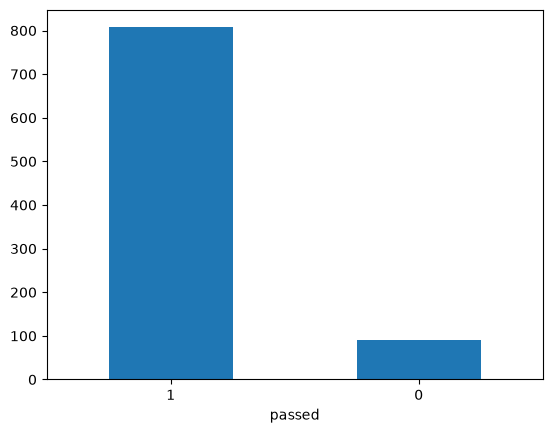

In [161]:
df.passed.value_counts().plot(
    kind='bar')
plt.xticks(rotation=0)    
plt.show()

if we were to split our data into pass and fail classes with A, B & C as pass and D & F as fail we'd have 899 samples in the pass class and 101 samples in the fail class. in an ideal world all of our target classes have the same number of samples (so that the model is equally good at identifying/labelling either class).

In [162]:
print(f"""after splitting our data into fail and pass classes we have a pass class with a sample size of {len(df[df.passed==1])}
and a fail class with a sample size of {len(df[df.passed==0])}. i'm including this python code to show that 'hard-coded' values aren't always the best option;
in the markdown cell above my sample sizes were calculated before we dropped nulls in the parental_education column.

using an f-string i can add code or variable names inside curly braces that update in real-time as values change!""")

after splitting our data into fail and pass classes we have a pass class with a sample size of 807
and a fail class with a sample size of 91. i'm including this python code to show that 'hard-coded' values aren't always the best option;
in the markdown cell above my sample sizes were calculated before we dropped nulls in the parental_education column.

using an f-string i can add code or variable names inside curly braces that update in real-time as values change!


### Exploring Relationships between Variables
while we could begin making comparisons between certain features and our targets (and you(you specifically) can) e.g. study_time_hours and passed (*does more studying lead to better results?*) or extracurricular_activites and study_time_hours or passed (*do extracurricular studies take away from study time or affect performance?*) to draw some inference, i'll jump straight to using a **correlation matrix** to see the extent to which each feature/independent variable impacts our target variable (because i'm tired and want to stop for today soon).

a correlation matrix; corr_matrix, is simply a big table of numbers telling us how related each variable is to the another. trouble is... it only work with numeric types.

we'll start by 'fixing' the binary columns; Yes/No and Male/Female columns; first error i got was a `ValueError: could not convert string to float: 'Male'` 

In [163]:
binary_cols = ['internet_access', 'extracurricular_activities', 'part_time_job']
df[binary_cols] = df[binary_cols].replace({'Yes': 1, 'No': 0})
# and
df.gender = df.gender.replace({'Male': 1, 'Female': 0}) # replace() is a pretty straightforward method

df.head(10)

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade,passed
0,1,1,4.0,98.0,6.5,Bachelors,1,1,0,76.9,100.0,A,1
1,2,0,6.3,100.0,5.7,High School,1,1,1,75.5,100.0,A,1
2,3,1,4.9,85.3,7.9,Bachelors,1,0,1,88.5,97.3,A,1
4,5,1,2.2,89.6,4.6,Bachelors,1,0,1,61.8,68.3,D,0
5,6,0,4.2,78.2,5.7,High School,1,0,0,79.8,81.6,B,1
6,7,1,1.5,100.0,5.0,High School,1,1,1,58.6,69.6,D,0
7,8,1,6.2,86.4,6.0,High School,1,1,0,78.4,88.0,B,1
8,9,1,5.3,81.3,6.7,Bachelors,1,0,0,63.8,84.4,B,1
9,10,0,2.8,86.8,5.1,Bachelors,1,1,0,57.7,74.3,C,1
10,11,1,0.9,71.5,5.7,High School,1,0,1,73.4,68.9,D,0


what remains is `parental_education` and `final_grade`. both of which are **ordinal categories**; categories that have an inherent order; education levels, test scores. we need to assign meaningful numeric ranks so that the correlation matrix captures the relationship accurately.

In [164]:
df.parental_education.unique() # to get the distinct education levels

<StringArray>
['Bachelors', 'High School', 'Masters', 'PhD']
Length: 4, dtype: str

In [165]:
df.final_grade.unique() # to get the distinct grades

<StringArray>
['A', 'D', 'B', 'C', 'F']
Length: 5, dtype: str

In [166]:
education_order = {
    "High School": 1,
    "Bachelors": 2,
    "Masters": 3,
    "PhD": 4
}
# we create a dictionary with a logical ranking of identified education levels before mapping values
# in the column to the keys(rank number) in the dictionary using the map() method
df['parental_education_num'] = df.parental_education.map(education_order)

# on to the grade with a logical ranking of present grades. grade A has a higher value/ranks higher
# if this assumption ends up to be faulty we could always make changes to the dictionary
scored_grade = {
    "A": 5,
    "B": 4,
    "C": 3,
    "D": 2,
    "F": 1
}
df['grade_num'] = df.final_grade.map(scored_grade)

df.head(10)


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade,passed,parental_education_num,grade_num
0,1,1,4.0,98.0,6.5,Bachelors,1,1,0,76.9,100.0,A,1,2,5
1,2,0,6.3,100.0,5.7,High School,1,1,1,75.5,100.0,A,1,1,5
2,3,1,4.9,85.3,7.9,Bachelors,1,0,1,88.5,97.3,A,1,2,5
4,5,1,2.2,89.6,4.6,Bachelors,1,0,1,61.8,68.3,D,0,2,2
5,6,0,4.2,78.2,5.7,High School,1,0,0,79.8,81.6,B,1,1,4
6,7,1,1.5,100.0,5.0,High School,1,1,1,58.6,69.6,D,0,1,2
7,8,1,6.2,86.4,6.0,High School,1,1,0,78.4,88.0,B,1,1,4
8,9,1,5.3,81.3,6.7,Bachelors,1,0,0,63.8,84.4,B,1,2,4
9,10,0,2.8,86.8,5.1,Bachelors,1,1,0,57.7,74.3,C,1,2,3
10,11,1,0.9,71.5,5.7,High School,1,0,1,73.4,68.9,D,0,1,2


In [167]:
# the student_id does nothing for us! so we'll delete it
# we could have set it as the index while loading our data it but there's no need to do that at this point

corr_df = df.drop(columns='student_id')
corr_matrix = corr_df.corr(numeric_only=True)
corr_matrix

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score,passed,parental_education_num,grade_num
study_time_hours,1.000000,-0.038170,-0.000487,-0.018763,0.569709,0.298420,0.047856,0.528538
attendance_percent,-0.038170,1.000000,0.042109,-0.027596,0.259429,0.177282,0.011536,0.249324
sleep_hours,-0.000487,0.042109,1.000000,-0.004852,0.148645,0.082709,-0.020165,0.135196
previous_grade,-0.018763,-0.027596,-0.004852,1.000000,0.408702,0.191597,-0.011648,0.381499
final_exam_score,0.569709,0.259429,0.148645,0.408702,1.000000,0.605018,0.042177,0.954850
passed,0.298420,0.177282,0.082709,0.191597,0.605018,1.000000,0.064087,0.657540
parental_education_num,0.047856,0.011536,-0.020165,-0.011648,0.042177,0.064087,1.000000,0.061636
grade_num,0.528538,0.249324,0.135196,0.381499,0.954850,0.657540,0.061636,1.000000


i'm noticing that we have some repetitive columns/columns representing the same thing differently(`final_grade` and `passed` for example) that are giving us us 'false positives'. identify them if you want ✌🏾️🥀️

i'll delete them next time. exhausted. see you on wednesday if you want.

In [168]:
# we'll immediately pick up where we left off; dropping/deleting 'repetitive columns' and reordering our final columns
# i'm adding 'final_exam_score' and 'grade_num' because our prediction is focused on whether they passed
# or didn't pass, not how well the students performed (i drop them anyways before modeling)

repetitive_cols = ['parental_education', 'final_grade', 'final_exam_score', 'grade_num']
corr_df = corr_df.drop(columns=repetitive_cols)

corr_df = corr_df[[
    'gender', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'internet_access', 'extracurricular_activities', 'part_time_job', 
    'parental_education_num','previous_grade', 'passed']]

corr_df.columns

Index(['gender', 'study_time_hours', 'attendance_percent', 'sleep_hours',
       'internet_access', 'extracurricular_activities', 'part_time_job',
       'parental_education_num', 'previous_grade', 'passed'],
      dtype='str')

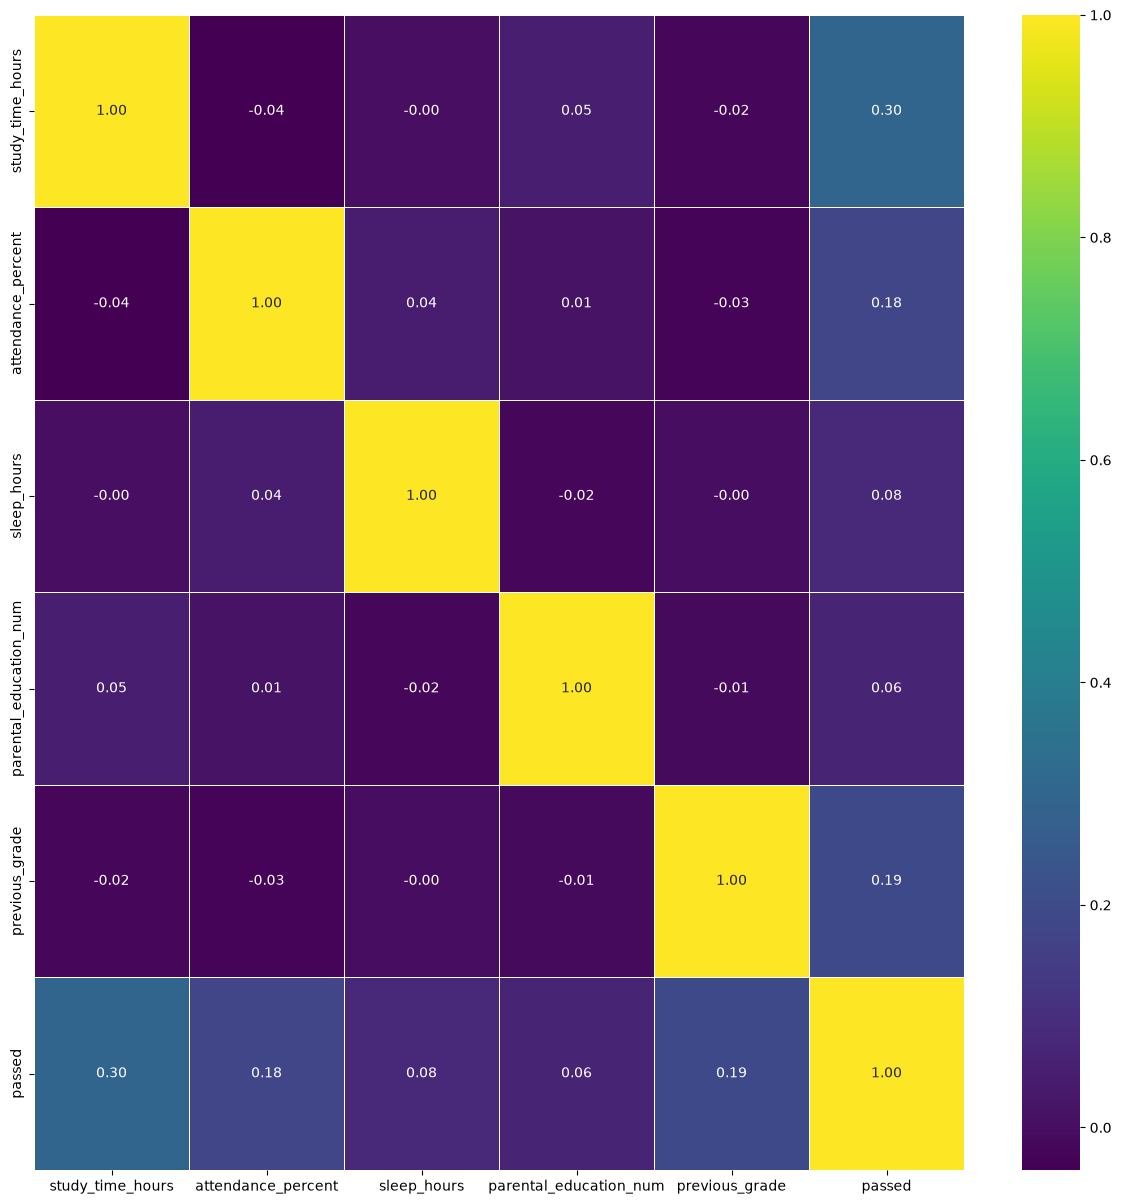

In [169]:
# let's recreate our correlation matrix and visualize

corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, 
            annot=True, 
            linewidths=0.5,
            fmt=".2f",
            cmap="viridis")
            
plt.show()

### Data Leakage (updated)
having features/columns generated from what is practically our target variable may result in the display of less meaningful relationships in our correlation matrix e.g. overly strong relationships between `final_exam_score`, `grade_num`, `passed` which are all different representation of the same variable/feature.

if we were to include  these features in our training data when modeling the model wouldn't really 'learn the relationship' we're trying to get it to learn; `whether a student will pass or fail based on their habits and other relevant/available metrics`. it would instead cheat on the tests/testing data because it pretty much has all the right answers. the result would be a model that perform really well on testing data but fails in deployment.

when a machine learning model gets access to information during training that it won't have when making predictions (in deployment for example) that is data leakage. in our scenario there could be **target leakage** if we fail to drop the previously mentioned columns; the training data includes features that contain the answer or reflect the target outcome.

if perhaps we wanted to make a prediction at the begining of the semester for example on whether a student would pass or fail that semester then we wouldn't have acces to or be using the students' final grade. including this in our trainig data would result in **temporal leakage**; where future data is used to train a model meant to predict past or present events, which is a common mistake in time-series data.

to intuit what constitutes data leakage ask yourself; `would I actually have this information at the moment I need to make the prediction?`

on to modeling!

### Modeling
it's time to split our target variable (`passed`) from the features before reuniting with train_test_split.

- `X` - our features
- `y` - our target variable

In [170]:
X = corr_df.drop(columns=['passed'])
y = corr_df.passed

In [171]:
X.head(3)

,gender,study_time_hours,attendance_percent,sleep_hours,internet_access,extracurricular_activities,part_time_job,parental_education_num,previous_grade
0,1,4.0,98.0,6.5,1,1,0,2,76.9
1,0,6.3,100.0,5.7,1,1,1,1,75.5
2,1,4.9,85.3,7.9,1,0,1,2,88.5


In [172]:
y.head(3)

0    1
1    1
2    1
Name: passed, dtype: int64

### train_test_split
scikit-learn has a module `sklearn.model_selection.train_test_split()` which as the descriptive name suggests splits our data into two, a training set and a testing set.
- from the `training set` the model learns the patters in the dataset to be able to make predictions on similar but unseen samples
- it is on the `testing set` that trained model is evaluated; this is the first batch of 'similar but unseen samples' from which data scientists and ml engineerings find out whether the model is any good at making predictions accurately before deploying it/making it publicly* available for use.

the split is usually roughly a **70-30/80-20** percent of the dataset for training and testing respectively

In [173]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"""
{len(X_train)},{len(y_train)}; training features and training targets

{len(X_test)},{len(y_test)}; testing features and testing targets
""")


718,718; training features and training targets

180,180; testing features and testing targets



everything looks balanced. on to
### Model Selection
we're familiar with our problem; a classification problem. the scikit-learn library and machine learning in general has multiple models from which we can choose for a particular problem. data science and ml is an **iterative process**; we can have multiple different runs/attempts to reach a solution and pick the best one/the one that gets us as close as possible to our desired outcome.

you'll familiarize yourself with more of these tools as you spend more time learning and working on different projects. there's some nuance to model selection even if they all perform the same type of task. for this data i've selected **Logistic Regression** and **Random Forest Classifier**.

tl;dr: when you're starting out prioritize understanding your problem first followed by what tools are available to solve that specific problem.

we'll try out both models in one go and score them (rate them on accuracy) to pick one to continue working with/improving on.


In [174]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000), # max_iter tells the model how many repetions it has to get to an optimal solution; you don't want to set it too low
    "Random Forest": RandomForestClassifier()
}

# in ml-stuff..pdf there's an 'outline' of what training a model; fitting, is like;
# model = LogisticRegression()
# model.fit(X_train, y_train)
# predictions = model.predict(X_test)
# we'll write a function that makes use of a for loop to loop over model in models
#  and 'fits' them on our splits (we need both the train and test splits) then returns their respective scores

def model_fitter_scorer(models, X_train, X_test, y_train, y_test):
    """
    remeber docstrings? you can add one to this function
    """

    np.random.seed(42)
    model_scores = {}
    
    for name, model in models.items():
        model.fit(X_train, y_train)  # fit/train the model on the data
        model_scores[name] = model.score(X_test, y_test) # evaluate the model and append its score to model_scores
    return model_scores


# fitting; the model attends class, learns
# scoring; the model takes a test to prove it's learned and there's a marking scheme to check against
# now we have a callable function 😃

In [175]:
model_scores = model_fitter_scorer(models=models,
                    X_train=X_train,
                    X_test=X_test,
                    y_train=y_train,
                    y_test=y_test) # my suspicion is that there's a more elegant way to write this function

model_scores

{'Logistic Regression': 0.9333333333333333,
 'Random Forest': 0.9333333333333333}

### Model Comparison 
let's make another visual for comparison (you might be working with more than two models in the future with varying scores)

we'll use the `DataFrame` constructor (refer to Pandas first class) to create a DataFrame from our model_scores dictionary make a plot from that. (one of the most "popular" ways to demonstrate making a DataFrame is by using a dictionary)

In [176]:
print(f"well damn! we hit {model_scores[list(model_scores)[0]]:.2f} and {model_scores[list(model_scores)[1]]:.2f} accuracy right off the bat with both models.")

# :.2f rounds the values off to 2 decimal points... or is it 2 floating points?
# the full colon is just syntax

well damn! we hit 0.93 and 0.93 accuracy right off the bat with both models.


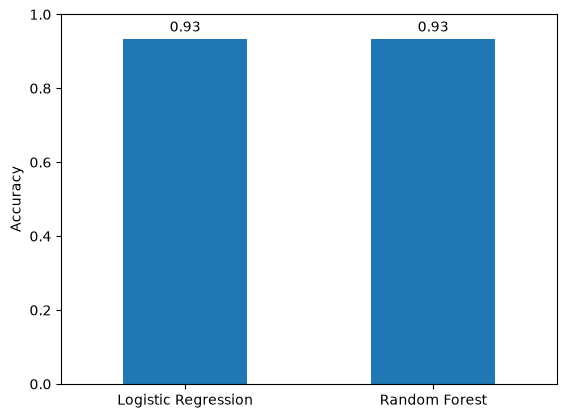

In [177]:
model_scores_df = pd.DataFrame(model_scores, index=['accuracy'])

ax = model_scores_df.T.plot.bar(legend=False)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3) # for readability
plt.ylim(0, 1) # so that our labels aren't cut off
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

### So how'd it go ?
our findings show that Logistic Regression is the best algorithm for predicting whether a student fails or passes with 93% accuracy. and we got such a high score without having to worry about **hyperparameter tuning**!

quick question though... is accuracy all we need to consider when training our classification algorithms?

we'll stop here for today i guess.

(picking up straight from where we left off)
### Hyperparameters & Hyperparameter Tuning and Cross-Validation
the same model can yield different results when trained on the same data. different algorithms have 'different knobs' that you can twist and turn to get things just right or to remedy some mistakes. these knobs/settings that different machine learning algorithms have that we can change to get different results are what we refer to as **hyperparameters**.

the 'mistakes' mentioned earlier can be of two kinds;
- model **overfitting**: performs really well on the training data (alone); can't generalize on new/unseen data. a crammer, not *really* smart
- model **underfitting**: fails to learn the relationship/detect the patterns in the training data. a dumbo

to get a model that isn't plagued by either we can test different hyperparameters using either a [validation set](https://www.geeksforgeeks.org/machine-learning/training-vs-testing-vs-validation-sets/)(suitable for data with large(r) samples as creating a validation set reduces the number of samples available to actually train the model).

enter **cross-validation**(cv), specifically *k*-fold cv, which involves
1. splitting your training data in to *k* different splits,
2. using each *k* or split to train and test the model with different hyperparameters settings on each run
the returned performance measure is an average of the values computed in the loop.

**note**: cross-validation can be done independently of hyperparameter tuning/just evaluating a model across multiple splits using scikit-learn's `cross_val_score`. we'll be using `RandomizedSearchCV` to perform cross-validation *as a means* to find the best hyperparameter setting

*ps thank the heavens for scikit-learn and all the abstractions they provide. you just need to know what to use and when; worry not about how. for the most part at least.*


### (vanilla) Cross Validation

In [178]:
model = LogisticRegression(max_iter=1000)

scoring={
        "accuracy": "accuracy",
        "f1": "f1",
        "precision": "precision",
        "recall": "recall"
    }

cv_scores = cross_validate(
    model,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

cv_scores_df = pd.DataFrame(cv_scores)
cv_scores_df.insert(0, "fold", range(1, len(cv_scores_df) + 1))

cv_scores_df

,fold,fit_time,score_time,test_accuracy,test_f1,test_precision,test_recall
0,1,0.764493,0.017441,0.888889,0.938931,0.924812,0.953488
1,2,0.864352,0.024549,0.902778,0.948529,0.902098,1.000000
2,3,0.530634,0.018219,0.902778,0.946154,0.938931,0.953488
3,4,0.301489,0.019899,0.923077,0.958801,0.927536,0.992248
4,5,0.289723,0.016924,0.895105,0.942529,0.931818,0.953488


In [179]:
eval_metrics = cv_scores_df[["test_accuracy", "test_f1", "test_precision", "test_recall"]]
eval_metrics.mean()

test_accuracy     0.902525
test_f1           0.946989
test_precision    0.925039
test_recall       0.970543
dtype: float64

let's talk about 
### Classification Evaluation Metrics
and consider which one matters most to us/why accuracy isn't everything
- **Accuracy**: the ratio of correct predictions to total predictions; most useful when classes are balanced but misleading when they are imbalanced (like ours is)

- **Precision**: a measure of the proportion of true positives(true labelled as true) over the total number of samples; important when false positives(false labelled as true) are costly

- **Recall**: a measure of the proportion of true positives over total number of true positives and false negatives(true labelled as false); important when missing a positive is dangerous

- **F1 score**: combines precion and recall into one metric by finding the harmonic mean; 1 is best, 0 is worst

try thinking about these metrics in a clinical setting to understand why each is crucial in a differnt way; mislabelling a sick patient as ready for discharge (false negative), siging up a patient for a drug trial they don't need(false positive) and missing patients who actually do(true positives)

`there's one more metric...`

now we'll revisit our model and find the best hyperparameter settings using (non-vanilla) cross validation.

```Python
model = LogisticRegression(
    C=1.0,
    max_iter=1000
)
```

`C` can be a hyperpameter in logistic regression; it controls the strength of regularization controlling how the model fits onto the data. instead of guessing the best value of C that yields the best results, we can use scikit-learn to test several possibilities for us.

### differentiating (function) Parameters and model Hyperparameters *(and model Parameters)*
from previous classes we've encountered the concept of and written functions. some functions are supplied arguments *or parameters* that change/dictate how the function executes code.

in the snippet above, the items in brackets are parameters of the LogisticRegression estimator (a type of function?). in machine learning terminology, they're generally called hyperparameters because they're the setting chosen *before* training rather than parameters learned from the data (for example, early in the llm race new companies would always preface a launch by mentioning how many parameters their new model had/was operating on)

In [180]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

param_distributions = {
    "C": loguniform(0.001, 100),
    "class_weight": [None, "balanced"] # because of our imbalanced classes; pass samples are significantly higher than fail samples, we might want to experiment with this parameter as well
}

# here in param_distribution or random_space (conventional name) is where we place the configurable parameter/twistable knobs we want to 'search over'
# to find the best performing ones/best settings

model_tuner = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=20, # number of iterations/runs
    cv=5, # number of splits our training data is separated in to
    scoring=scoring,
    refit="f1",
    random_state=42
)

model_tuner.fit(X_train, y_train) # during this fitting/training process 20 * 5 operations happen from which we'll get our 'bests'

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': <scipy.stats....x7f7c698595b0>, 'class_weight': [None, 'balanced']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or N

In [181]:
print("best cv f1:", model_tuner.best_score_)
# returns the best f1 score gotten after those 20 runs

print("best parameters:", model_tuner.best_params_) 
# returns the best settings for our hyperparameters; C and class_weight, found after all 20 runs on each of our 5 splits

best cv f1: 0.9518080794601784
best parameters: {'C': np.float64(0.21568228019263963), 'class_weight': None}


In [182]:
tuned_model = model_tuner.best_estimator_
# best_estimator_ 'sets' model_tuner to run the logistic regression model with the 'best parameters';
# whatever hyperparameters resulted in the best score on the scoring method we 'refitted' our model on; f1 score

test_accuracy = tuned_model.score(X_test, y_test)
print("test accuracy:", test_accuracy)

test accuracy: 0.9388888888888889


our model is performing only marginally better that it did before tuning... we'll take it 🗣️!

note from elsewhere: `many of the algorithms in scikit-learn have pretty good default hyperparameter values so don't be surprised if they perform pretty good on your data straight out of the box which isn't true all the time; just because the default hyperparameters perform pretty well on your data doesn't mean there aren't a better set of hyperparameter values out there.`

we could further tune our current model using another cross-validation search. we could even chain it together with another model(s) to try getting even better predictions. of course we won't be doing that here but you can.

an **iterative process** am i right ?

you won't believe over 4 hours have passed *today*... *inside this notebook*. i'm learning as much as i'm teaching at this point. which is... great 🗣️! 

anyways, we'll be wrapping up with a confusion matrix and a classification report